# Advanced Retail Analytics & Revenue Optimization System
## Data Analytics and Machine Learning

**Dataset:** [Online Retail II UCI — Kaggle](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

**Project Goals:**
1. Setup
2. Data Loading
3. Exploratory Analysis
4. Revenue Oppurtunity Analysis
5. Demand Forecasting
6. Promotion Analysis
7. Tableau Export


## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries imported")


Libraries imported


## 2. Data Loading

The **Online Retail II** dataset contains all transactions from a UK-based online retailer (Dec 2009 – Dec 2011). 

**Expected columns:**  
`Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`, `Customer ID`, `Country`


In [2]:
# loading the retail dataset
# keeping customer id and stock code as strings so formatting doesn't get messed up
df_raw = pd.read_csv(
    "online_retail_II.csv",
    encoding="latin-1",
    dtype={"Customer ID": str, "StockCode": str}
)

print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

print("\nMissing values:")
print(df_raw.isna().sum())

df_raw.head()


Shape: (1067371, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data Cleaning & Feature Engineering

Key cleaning steps:
- Remove **cancellations** (Invoice starting with 'C')
- Drop rows with missing **Customer ID** or **Description**
- Remove transactions with **Quantity ≤ 0** or **Price ≤ 0**
- Parse `InvoiceDate`, convert the string
- Engineer: `Revenue`, `Month`, `DayOfWeek`, `Hour`, `Category`, `IsPromotion`


In [3]:
df = df_raw.copy()

# remove cancelled invoices
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# remove rows where key fields are missing
df = df.dropna(subset=["Customer ID", "Description"])

# keeping only normal purchase rows
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)].copy()

# convert to datetime so time-based analysis is easier later
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# time columns
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["Hour"] = df["InvoiceDate"].dt.hour
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# line-level revenue
df["Revenue"] = df["Quantity"] * df["Price"]

# simple category grouping from stock code
# not perfect, but useful for higher-level analysis
def get_category(code):
    code = str(code).strip().upper()
    
    if not code:
        return "Miscellaneous"
    
    first = code[0]

    if first in ["8", "9"]:
        return "Home & Living"
    elif first in ["2", "3"]:
        return "Gifts & Novelties"
    elif first in ["4", "5"]:
        return "Seasonal & Holiday"
    elif first == "7":
        return "Stationery & Cards"
    elif first == "6":
        return "Kitchen & Dining"
    elif first == "1":
        return "Baby & Kids"
    elif first.isalpha():
        return "Apparel & Accessories"
    else:
        return "Miscellaneous"

df["Category"] = df["StockCode"].apply(get_category)

# marking rows where price looks meaningfully below the usual sku price
sku_median_price = df.groupby("StockCode")["Price"].transform("median")
df["IsPromotion"] = (df["Price"] < sku_median_price * 0.9).astype(int)

# keeping sample size manageable and consistent
np.random.seed(42)
if len(df) > 328000:
    df = df.sample(328000, random_state=42).reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Unique customers:", df["Customer ID"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Total revenue: ${:,.2f}".format(df["Revenue"].sum()))
print("Date range:", df["InvoiceDate"].min().date(), "to", df["InvoiceDate"].max().date())

print("\nCategory counts:")
print(df["Category"].value_counts())

Cleaned shape: (328000, 16)
Unique customers: 5761
Unique products: 4478
Total revenue: $7,202,293.15
Date range: 2009-12-01 to 2011-12-09

Category counts:
Gifts & Novelties        258667
Home & Living             47190
Seasonal & Holiday         9232
Stationery & Cards         6456
Baby & Kids                5176
Apparel & Accessories      1152
Kitchen & Dining            127
Name: Category, dtype: int64


## 4. Exploratory Data Analysis (EDA)

Explore revenue patterns across time and product categories 


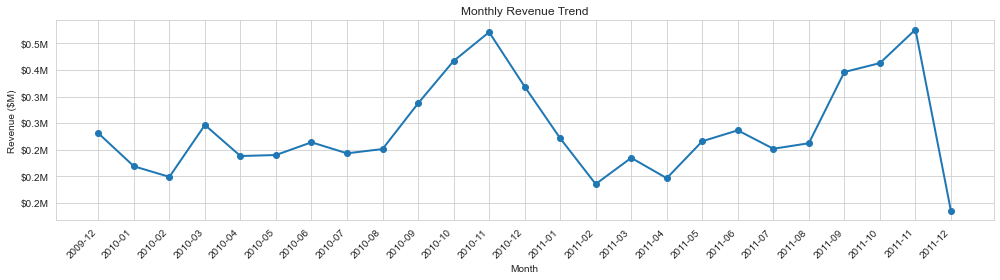

Highest month: 2011-11
Revenue: $475,734.27


In [4]:
monthly_rev = (
    df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("YearMonth")
)

monthly_rev["YearMonth_str"] = monthly_rev["YearMonth"].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(
    monthly_rev["YearMonth_str"],
    monthly_rev["Revenue"] / 1e6,
    marker="o",
    linewidth=2
)

ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($M)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1fM"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart_01_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

top_month = monthly_rev.loc[monthly_rev["Revenue"].idxmax()]
print("Highest month:", top_month["YearMonth_str"])
print("Revenue: ${:,.2f}".format(top_month["Revenue"]))


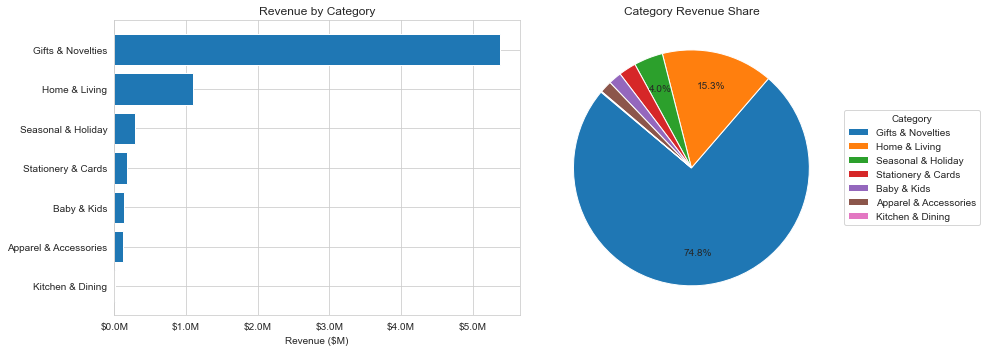

             Category  Revenue_M  Share_%  Transactions
    Gifts & Novelties       5.39    74.78         32250
        Home & Living       1.10    15.30         19196
   Seasonal & Holiday       0.29     3.99          6372
   Stationery & Cards       0.17     2.39          4666
          Baby & Kids       0.13     1.79          3771
Apparel & Accessories       0.12     1.65          1127
     Kitchen & Dining       0.01     0.11           116


In [5]:
cat_df = (
    df.groupby("Category")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("Invoice", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

cat_df["Revenue_M"] = cat_df["Revenue"] / 1e6
cat_df["Share_%"] = 100 * cat_df["Revenue"] / cat_df["Revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart
axes[0].barh(cat_df["Category"][::-1], cat_df["Revenue_M"][::-1])
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Revenue ($M)")
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1fM"))

# pie chart
def pct_label(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

wedges, texts, autotexts = axes[1].pie(
    cat_df["Share_%"],
    autopct=pct_label,
    startangle=140,
    pctdistance=0.72
)

axes[1].set_title("Category Revenue Share")
axes[1].legend(
    wedges,
    cat_df["Category"],
    title="Category",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.savefig("chart_02_category_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

print(cat_df[["Category", "Revenue_M", "Share_%", "Transactions"]].to_string(index=False))


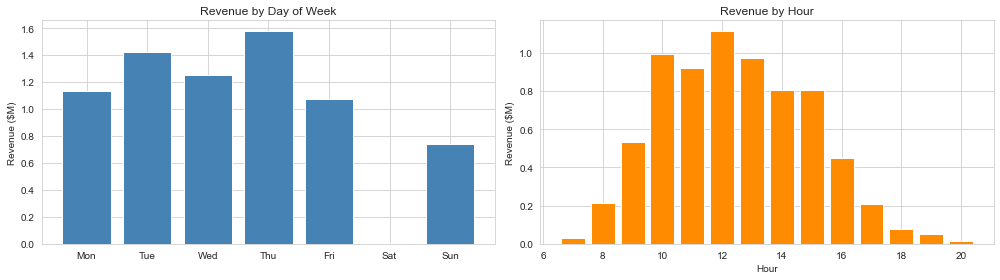

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

day_rev = df.groupby("DayOfWeek")["Revenue"].sum()
axes[0].bar([day_names[i] for i in day_rev.index], day_rev.values / 1e6, color="steelblue")
axes[0].set_title("Revenue by Day of Week")
axes[0].set_ylabel("Revenue ($M)")

hour_rev = df.groupby("Hour")["Revenue"].sum()
axes[1].bar(hour_rev.index, hour_rev.values / 1e6, color="darkorange")
axes[1].set_title("Revenue by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Revenue ($M)")

plt.tight_layout()
plt.savefig("chart_03_time_patterns.png", dpi=150, bbox_inches="tight")
plt.show()


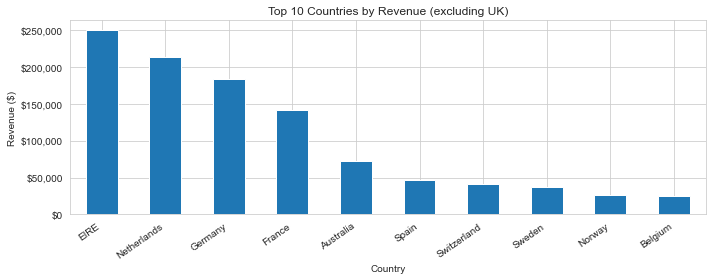

In [7]:
country_df = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
country_df.plot(kind="bar", ax=ax)

ax.set_title("Top 10 Countries by Revenue (excluding UK)")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("chart_04_country_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Revenue Optimization

We combine three analytical lenses to surface unrealised revenue:

| # | Lens | Method |
|---|------|--------|
| 1 | **Pricing gaps** | Lift underpriced SKUs to category 75th-percentile price |
| 2 | **Basket uplift** | Lift low-basket customers to the median basket value |
| 3 | **At-risk retention** | Recover lapsed customers at 30% win-back rate |


In [8]:
# trying to estimate where products may be priced below their category range

sku_df = (
    df.groupby(["StockCode", "Category"])
    .agg(
        avg_price=("Price", "mean"),
        units_sold=("Quantity", "sum"),
        revenue=("Revenue", "sum")
    )
    .reset_index()
)

cat_price = (
    df.groupby("Category")["Price"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"Price": "cat_p75"})
)

sku_df = sku_df.merge(cat_price, on="Category", how="left")

sku_df["price_gap"] = (sku_df["cat_p75"] - sku_df["avg_price"]).clip(lower=0)
sku_df["revenue_gap"] = sku_df["price_gap"] * sku_df["units_sold"]

pricing_opportunity = sku_df["revenue_gap"].sum()

print("Estimated pricing opportunity: ${:,.2f}".format(pricing_opportunity))


Estimated pricing opportunity: $9,802,442.85


In [9]:
cust_df = (
    df.groupby("Customer ID")
    .agg(
        total_revenue=("Revenue", "sum"),
        order_count=("Invoice", "nunique")
    )
    .reset_index()
)

cust_df["avg_basket"] = cust_df["total_revenue"] / cust_df["order_count"]

basket_cutoff = cust_df["avg_basket"].quantile(0.25)
median_basket = cust_df["avg_basket"].median()

low_basket_customers = cust_df[cust_df["avg_basket"] < basket_cutoff].copy()

basket_opportunity = (
    (median_basket - low_basket_customers["avg_basket"]) *
    low_basket_customers["order_count"]
).sum()

print("Estimated basket uplift opportunity: ${:,.2f}".format(basket_opportunity))
print("Customers below 25th percentile:", len(low_basket_customers))
print("Median basket value: ${:,.2f}".format(median_basket))


Estimated basket uplift opportunity: $307,521.99
Customers below 25th percentile: 1440
Median basket value: $120.55


In [10]:
# using recency to flag customers who look relatively inactive

snapshot_date = df["InvoiceDate"].max()

last_order = df.groupby("Customer ID")["InvoiceDate"].max()
recency_days = (snapshot_date - last_order).dt.days

at_risk_cutoff = recency_days.quantile(0.75)
at_risk_ids = recency_days[recency_days >= at_risk_cutoff].index

cust_indexed = cust_df.set_index("Customer ID")
avg_spend_at_risk = cust_indexed.loc[
    cust_indexed.index.isin(at_risk_ids), "total_revenue"
].mean()

retention_opportunity = 0.30 * len(at_risk_ids) * avg_spend_at_risk

print("Estimated retention opportunity: ${:,.2f}".format(retention_opportunity))
print("At-risk customers:", len(at_risk_ids))
print("Average historical spend: ${:,.2f}".format(avg_spend_at_risk))


Estimated retention opportunity: $132,836.00
At-risk customers: 1442
Average historical spend: $307.06


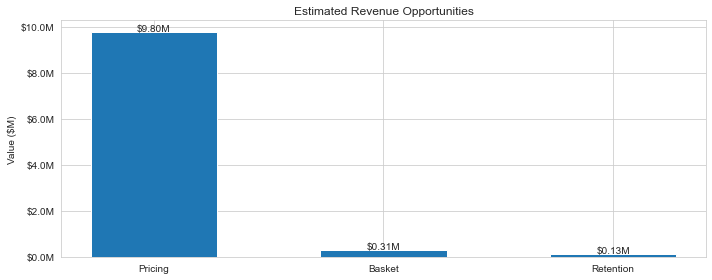

Total estimated opportunity: $10,242,800.84


In [11]:
total_opp = pricing_opportunity + basket_opportunity + retention_opportunity

opp_names = ["Pricing", "Basket", "Retention"]
opp_values = [pricing_opportunity, basket_opportunity, retention_opportunity]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(opp_names, [x / 1e6 for x in opp_values], width=0.55)

ax.set_title("Estimated Revenue Opportunities")
ax.set_ylabel("Value ($M)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1fM"))

for bar, val in zip(bars, opp_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"${val/1e6:.2f}M",
        ha="center"
    )

plt.tight_layout()
plt.savefig("chart_05_revenue_opportunities.png", dpi=150, bbox_inches="tight")
plt.show()

print("Total estimated opportunity: ${:,.2f}".format(total_opp))


## 6. ML Demand Forecasting — Random Forest & Gradient Boosting

We forecast **weekly demand (units)** per product category.

The train/test split is **time-ordered** (last 20% of weeks = test) to avoid data leakage 

ISOYear, Week : Calender position,
Category_enc : Label-encoded product category,
promo_rate : Fraction of transactions that were promotional that week,
lag1_demand : Demand in the previous week (same category),
roll4_demand : 4-week rolling average demand,
roll8_demand : 8-week rolling average demand


In [12]:
df["ISOYear"] = df["InvoiceDate"].dt.isocalendar().year.astype(int)
df["ISOWeek"] = df["InvoiceDate"].dt.isocalendar().week.astype(int)

weekly = (
    df.groupby(["ISOYear", "ISOWeek", "Category"])
    .agg(
        demand=("Quantity", "sum"),
        promo_rate=("IsPromotion", "mean")
    )
    .reset_index()
    .sort_values(["Category", "ISOYear", "ISOWeek"])
    .reset_index(drop=True)
)

print("Weekly table shape:", weekly.shape)
weekly.head(8)


Weekly table shape: (683, 5)


,ISOYear,ISOWeek,Category,demand,promo_rate
0,2009,49,Apparel & Accessories,12,0.25
1,2009,50,Apparel & Accessories,32,0.07
2,2009,51,Apparel & Accessories,30,0.14
3,2009,52,Apparel & Accessories,2,0.00
4,2010,1,Apparel & Accessories,26,0.29
5,2010,2,Apparel & Accessories,30,0.25
6,2010,3,Apparel & Accessories,11,0.00
7,2010,4,Apparel & Accessories,18,0.56


In [13]:
encoder = LabelEncoder()
weekly["Category_enc"] = encoder.fit_transform(weekly["Category"])

weekly = weekly.sort_values(["Category", "ISOYear", "ISOWeek"]).reset_index(drop=True)

# using lagged demand so the model only sees past information
weekly["lag1_demand"] = weekly.groupby("Category")["demand"].shift(1)

weekly["roll4_demand"] = (
    weekly.groupby("Category")["demand"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=2).mean())
)

weekly["roll8_demand"] = (
    weekly.groupby("Category")["demand"]
    .transform(lambda s: s.shift(1).rolling(8, min_periods=4).mean())
)

weekly = weekly.dropna(subset=["lag1_demand", "roll4_demand", "roll8_demand"]).reset_index(drop=True)

features = [
    "ISOYear",
    "ISOWeek",
    "Category_enc",
    "promo_rate",
    "lag1_demand",
    "roll4_demand",
    "roll8_demand"
]

target = "demand"

X = weekly[features]
y = weekly[target]

split_idx = int(len(X) * 0.80)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Features used:", features)

Train rows: 524
Test rows: 131
Features used: ['ISOYear', 'ISOWeek', 'Category_enc', 'promo_rate', 'lag1_demand', 'roll4_demand', 'roll8_demand']


In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

mape_rf = np.mean(np.abs((y_test.values - rf_pred) / y_test.clip(lower=1).values)) * 100
acc_rf = 100 - mape_rf
r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test, rf_pred)

print("Random Forest results")
print("MAE:", round(mae_rf, 1))
print("R^2:", round(r2_rf, 4))
print("Accuracy (100 - MAPE): {:.1f}%".format(acc_rf))


Random Forest results
MAE: 555.1
R^2: -1.2392
Accuracy (100 - MAPE): 15.1%


In [15]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

mape_gb = np.mean(np.abs((y_test.values - gb_pred) / y_test.clip(lower=1).values)) * 100
acc_gb = 100 - mape_gb
r2_gb = r2_score(y_test, gb_pred)
mae_gb = mean_absolute_error(y_test, gb_pred)

print("Gradient Boosting results")
print("MAE:", round(mae_gb, 1))
print("R^2:", round(r2_gb, 4))
print("Accuracy (100 - MAPE): {:.1f}%".format(acc_gb))

if acc_gb >= acc_rf:
    best_name = "Gradient Boosting"
    best_acc = acc_gb
else:
    best_name = "Random Forest"
    best_acc = acc_rf

print("\nBest model:", best_name)
print("Best accuracy: {:.1f}%".format(best_acc))


Gradient Boosting results
MAE: 537.7
R^2: -0.9974
Accuracy (100 - MAPE): 20.5%

Best model: Gradient Boosting
Best accuracy: 20.5%


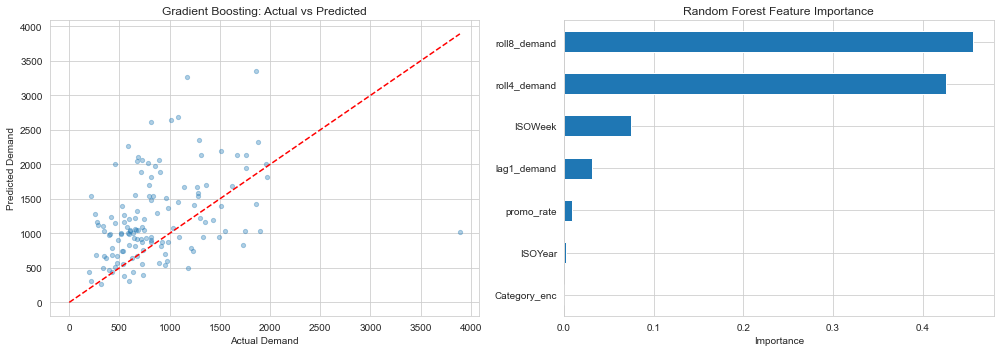

            Model    MAE    R2 Accuracy
    Random Forest 555.10 -1.24    15.1%
Gradient Boosting 537.70 -1.00    20.5%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_n = min(400, len(y_test))

axes[0].scatter(y_test.values[:sample_n], gb_pred[:sample_n], alpha=0.35, s=18)
max_val = max(y_test.values[:sample_n].max(), gb_pred[:sample_n].max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5)
axes[0].set_xlabel("Actual Demand")
axes[0].set_ylabel("Predicted Demand")
axes[0].set_title("Gradient Boosting: Actual vs Predicted")

imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.plot(kind="barh", ax=axes[1])
axes[1].set_title("Random Forest Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("chart_06_model_results.png", dpi=150, bbox_inches="tight")
plt.show()

results_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "MAE": [round(mae_rf, 1), round(mae_gb, 1)],
    "R2": [round(r2_rf, 4), round(r2_gb, 4)],
    "Accuracy": [f"{acc_rf:.1f}%", f"{acc_gb:.1f}%"]
})

print(results_df.to_string(index=False))

## 7. Hypothesis Testing — Impact of Promotions on Revenue

**H₀ (Null):** Promotional pricing has no significant effect on per-transaction revenue.  
**H₁ (Alternative):** Promotional pricing leads to significantly different per-transaction revenue.

We use **Welch's independent t-test** (does not assume equal variances) and report:
- p-value at α = 0.05
- Cohen's d (effect size)
- 95% confidence interval on the mean difference


In [17]:
promo_rev = df.loc[df["IsPromotion"] == 1, "Revenue"]
non_promo_rev = df.loc[df["IsPromotion"] == 0, "Revenue"]

print("Promo transactions:", len(promo_rev))
print("Promo mean revenue: ${:.2f}".format(promo_rev.mean()))
print("Promo median revenue: ${:.2f}".format(promo_rev.median()))

print()

print("Non-promo transactions:", len(non_promo_rev))
print("Non-promo mean revenue: ${:.2f}".format(non_promo_rev.mean()))
print("Non-promo median revenue: ${:.2f}".format(non_promo_rev.median()))


Promo transactions: 22833
Promo mean revenue: $107.67
Promo median revenue: $63.50

Non-promo transactions: 305167
Non-promo mean revenue: $15.54
Non-promo median revenue: $10.50


In [18]:
t_stat, p_value = stats.ttest_ind(promo_rev, non_promo_rev, equal_var=False)

alpha = 0.05

print("Welch's t-test")
print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 6))

if p_value < alpha:
    print("Result: significant difference at 5% level")
else:
    print("Result: not significant at 5% level")

Welch's t-test
t-statistic: 25.1575
p-value: 0.0
Result: significant difference at 5% level


In [19]:
pooled_std = np.sqrt((promo_rev.std()**2 + non_promo_rev.std()**2) / 2)
cohens_d = (promo_rev.mean() - non_promo_rev.mean()) / pooled_std

if abs(cohens_d) < 0.2:
    effect_label = "negligible"
elif abs(cohens_d) < 0.5:
    effect_label = "small"
elif abs(cohens_d) < 0.8:
    effect_label = "medium"
else:
    effect_label = "large"

print("Cohen's d:", round(cohens_d, 4))
print("Effect size:", effect_label)

Cohen's d: 0.2331
Effect size: small


In [20]:
n1 = len(promo_rev)
n2 = len(non_promo_rev)

diff = promo_rev.mean() - non_promo_rev.mean()
se_diff = np.sqrt(promo_rev.var() / n1 + non_promo_rev.var() / n2)

t_crit = stats.t.ppf(0.975, df=min(n1, n2) - 1)

ci_lo = diff - t_crit * se_diff
ci_hi = diff + t_crit * se_diff

print("Mean difference: ${:.2f}".format(diff))
print("95% CI: [${:.2f}, ${:.2f}]".format(ci_lo, ci_hi))

if p_value < alpha:
    if diff > 0:
        print("Promo transactions tend to generate higher revenue on average.")
    else:
        print("Promo transactions tend to generate lower revenue on average.")
else:
    print("The difference in average revenue is not statistically significant.")

Mean difference: $92.13
95% CI: [$84.95, $99.31]
Promo transactions tend to generate higher revenue on average.


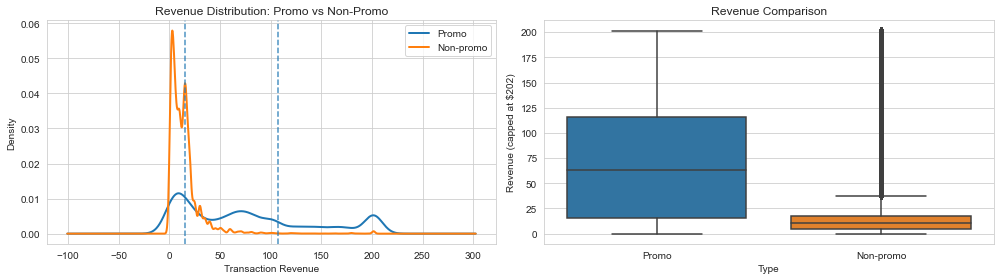

In [21]:
cap = df["Revenue"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

promo_rev.clip(upper=cap).plot.kde(ax=axes[0], label="Promo", linewidth=2)
non_promo_rev.clip(upper=cap).plot.kde(ax=axes[0], label="Non-promo", linewidth=2)

axes[0].axvline(promo_rev.mean(), linestyle="--", alpha=0.8)
axes[0].axvline(non_promo_rev.mean(), linestyle="--", alpha=0.8)
axes[0].set_title("Revenue Distribution: Promo vs Non-Promo")
axes[0].set_xlabel("Transaction Revenue")
axes[0].legend()

box_df = pd.DataFrame({
    "Revenue": pd.concat([
        promo_rev.clip(upper=cap),
        non_promo_rev.clip(upper=cap)
    ], ignore_index=True),
    "Type": (["Promo"] * len(promo_rev)) + (["Non-promo"] * len(non_promo_rev))
})

sns.boxplot(data=box_df, x="Type", y="Revenue", ax=axes[1])
axes[1].set_title("Revenue Comparison")
axes[1].set_ylabel(f"Revenue (capped at ${cap:.0f})")

plt.tight_layout()
plt.savefig("chart_07_hypothesis_testing.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Tableau Dashboard Export


In [22]:
tableau_monthly = (
    df.groupby(["YearMonth", "Category"])
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("Invoice", "nunique"),
        UnitsSold=("Quantity", "sum"),
        AvgBasket=("Revenue", "mean")
    )
    .reset_index()
)

tableau_monthly["YearMonth"] = tableau_monthly["YearMonth"].astype(str)
tableau_monthly.to_csv("tableau_monthly_category.csv", index=False)

print("Saved tableau_monthly_category.csv")
print("Rows:", len(tableau_monthly))

Saved tableau_monthly_category.csv
Rows: 172


In [23]:
rfm = cust_df.copy()
rfm["Recency_days"] = recency_days.values

rfm["R_score"] = pd.qcut(rfm["Recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["order_count"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["total_revenue"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_total"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def assign_rfm_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm["RFM_total"].apply(assign_rfm_segment)

rfm.to_csv("tableau_customer_rfm.csv", index=False)

print("Saved tableau_customer_rfm.csv")
print("\nSegment counts:")
print(rfm["Segment"].value_counts())

Saved tableau_customer_rfm.csv

Segment counts:
Potential Loyalists    1413
Loyal Customers        1355
Champions              1253
At Risk                 995
Lost                    745
Name: Segment, dtype: int64


In [24]:
opp_df = pd.DataFrame({
    "Opportunity": ["Pricing Gap", "Basket Uplift", "At-Risk Retention", "Total"],
    "Value_USD": [pricing_opportunity, basket_opportunity, retention_opportunity, total_opp],
    "Description": [
        "Potential gain from products priced below category benchmark",
        "Potential gain from increasing low basket-value customers",
        "Potential gain from reactivating inactive customers",
        "Combined estimate"
    ]
})

opp_df.to_csv("tableau_revenue_opportunities.csv", index=False)

print("Saved tableau_revenue_opportunities.csv")

print("\nProject summary")
print("Transactions analyzed:", len(df))
print("Estimated revenue opportunity: ${:,.2f}".format(total_opp))
print("Best forecasting model:", best_name)
print("Best model accuracy: {:.1f}%".format(best_acc))
print("Promotion test p-value:", round(p_value, 6))

Saved tableau_revenue_opportunities.csv

Project summary
Transactions analyzed: 328000
Estimated revenue opportunity: $10,242,800.84
Best forecasting model: Gradient Boosting
Best model accuracy: 20.5%
Promotion test p-value: 0.0
